# UJIAN AKHIR SEMESTER GENAP TAHUN AKADEMIK 2025/2026

**Mata Kuliah:** Pembelajaran Mesin (P) | **Kode MK:** EL4010  
**Penguji:** Ayu Mawadda Warohma, S.T., M.T.  
**Waktu:** 09:40–11:20 | **Tanggal:** 17-06-2026 | **Kelas:** TE6A | **Ruang:** B606  
**Sifat Ujian:** Buka Buku | **Semester:** VI | **SKS:** 4

| | |
|---|---|
| **Nama** | Agus Priyansah |
| **NIM** | 2327270005 |
| **Kelas** | TE6A |
| **Jenis Tugas** | Regression — Dataset Air Quality (No. 1) |

**Repositori:** https://github.com/Arcadiavr/uas-air-quality-regression

---
# SOAL 1 — Sub-CPMK-5 (Bobot 66,67%)

## 1. Studi Kasus

### Permasalahan yang Ingin Diselesaikan
Polusi udara perkotaan, terutama karbon monoksida (CO), berdampak pada kesehatan masyarakat dan kualitas lingkungan. Pengukuran konsentrasi gas polusi memerlukan alat referensi (analyzer) yang biaya operasi dan pemeliharaannya tinggi. Sensor gas berbasis metal oxide lebih murah, namun responsnya dipengaruhi suhu, kelembaban, dan cross-sensitivity antar gas.

Permasalahan dalam studi ini: **bagaimana memprediksi konsentrasi CO aktual (`CO(GT)`) berdasarkan respons sensor gas dan kondisi lingkungan**, sehingga sistem pemantauan kualitas udara dapat mengestimasi polusi dengan akurasi memadai.

### Kaitan dengan Bidang Teknik/Rekayasa
Studi ini berkaitan dengan **rekayasa lingkungan** dan **instrumentasi/sensor**. Machine learning berperan sebagai **model kalibrasi virtual** yang memetakan sinyal sensor ke konsentrasi gas nyata — pendekatan yang umum dalam sistem monitoring IoT dan smart city.

### Tujuan Penerapan Machine Learning
1. Membangun model regresi end-to-end untuk prediksi konsentrasi CO.
2. Mengevaluasi beberapa algoritma regresi dan memilih model terbaik.
3. Mengukur kemampuan generalisasi model melalui pembagian training, validation, dan testing.
4. Menyediakan model yang dapat digunakan untuk inferensi pada data baru.

## 2. Dataset

| Item | Detail |
|------|--------|
| Nama | Air Quality Data Set |
| Sumber | UCI Machine Learning Repository |
| Link | https://archive.ics.uci.edu/dataset/360/air+quality |
| Unduhan | https://archive.ics.uci.edu/static/public/360/air+quality.zip |
| Target | `CO(GT)` — konsentrasi CO aktual (mg/m³) |
| Fitur | Respons 5 sensor gas + suhu (T), kelembaban relatif (RH), kelembaban absolut (AH) |

**Referensi:**
1. De Vito, S., et al. (2008). *Sensors and Actuators B: Chemical*. https://doi.org/10.1016/j.snb.2008.01.035
2. UCI ML Repository: https://archive.ics.uci.edu/dataset/360/air+quality

In [1]:
# --- TAHAP 0: IMPORT LIBRARY & PERSIAPAN DATASET ---
import subprocess
import urllib.request
import zipfile
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
    subprocess.run(["pip", "install", "-q", "seaborn"], check=False)
except ImportError:
    IN_COLAB = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "CO(GT)"
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "AirQualityUCI.csv"
UCI_ZIP = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"

if not DATA_PATH.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zp = DATA_DIR / "air_quality.zip"
    print("Mengunduh dataset dari UCI...")
    urllib.request.urlretrieve(UCI_ZIP, zp)
    with zipfile.ZipFile(zp, "r") as zf:
        zf.extractall(DATA_DIR)

BASE_FEATURES = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)",
    "PT08.S5(O3)", "T", "RH", "AH",
]

sns.set_theme(style="whitegrid")
print(f"Environment: {'Google Colab' if IN_COLAB else 'Lokal'}")

Environment: Lokal


# **Penjelasan**

Pada bagian awal program, library **pandas** dan **numpy** digunakan untuk kebutuhan dasar pemrosesan data. Pandas berfungsi untuk membaca dataset dan mengubahnya menjadi format tabel (DataFrame) agar data lebih mudah dimanipulasi. Numpy digunakan untuk operasi perhitungan matematika yang mendasari proses komputasi pada algoritma pembelajaran mesin. Library **matplotlib** dan **seaborn** dipanggil untuk keperluan visualisasi data dalam bentuk grafik.

Dari modul **scikit-learn**, program mengimpor berbagai algoritma regresi (Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting), fungsi pembagian data (`train_test_split`), metrik evaluasi (MAE, MSE, R²), serta alat preprocessing seperti `SimpleImputer` dan `StandardScaler`. Variabel `RANDOM_STATE = 42` ditetapkan agar hasil pembagian data dan pelatihan model dapat direproduksi dengan hasil yang sama setiap kali dijalankan.

Program juga memeriksa apakah file dataset sudah ada di folder `data/`. Jika belum ditemukan — kondisi yang umum terjadi saat notebook dibuka di Google Colab — sistem akan secara otomatis mengunduh dataset dari UCI Machine Learning Repository menggunakan `urllib` dan mengekstrak file ZIP ke folder kerja. Daftar `BASE_FEATURES` mendefinisikan delapan fitur input dasar, yaitu respons lima sensor gas metal oxide serta variabel lingkungan suhu, kelembaban relatif, dan kelembaban absolut.

In [2]:
# --- TAHAP 1: DATA COLLECTION & CLEANING ---
df_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",", na_values=["-200", -200])
df_raw.columns = df_raw.columns.str.strip()
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if c == "" or c.startswith("Unnamed")], errors="ignore")

for col in BASE_FEATURES + [TARGET]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df = df_raw.dropna(subset=[TARGET]).copy()
print(f"Jumlah sampel awal: {len(df_raw)}")
print(f"Jumlah sampel setelah cleaning target: {len(df)}")
print(f"Jumlah fitur input dasar: {len(BASE_FEATURES)}")
df[BASE_FEATURES + [TARGET]].head()

Jumlah sampel awal: 9471
Jumlah sampel setelah cleaning target: 7674
Jumlah fitur input dasar: 8


,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,2.6
1,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,2.0
2,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,2.2
3,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,2.2
4,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,1.6


# **Penjelasan**

Baris kode ini merupakan implementasi tahap pengumpulan dan pembersihan data. Fungsi `pd.read_csv()` digunakan untuk membaca file dataset berformat CSV dengan parameter `sep=";"` karena dataset UCI menggunakan titik koma sebagai pemisah kolom, serta `decimal=","` karena format angka menggunakan koma sebagai pemisah desimal. Parameter `na_values=["-200", -200]` mendefinisikan bahwa nilai negatif dua ratus pada dataset ini merupakan penanda data hilang (missing value), bukan nilai pengukuran yang valid.

Setelah pembacaan, nama kolom dirapikan dengan `str.strip()` untuk menghilangkan spasi berlebih, dan kolom kosong atau kolom tanpa nama (`Unnamed`) dihapus karena tidak memiliki informasi. Seluruh fitur dan target dikonversi ke tipe numerik menggunakan `pd.to_numeric()`. Baris yang tidak memiliki nilai pada kolom target `CO(GT)` dihapus melalui `dropna(subset=[TARGET])`, karena baris tanpa target tidak dapat digunakan dalam pembelajaran regresi. Hasil akhir disimpan dalam variabel `df` yang siap untuk tahap eksplorasi dan modeling.

## 3. Exploratory Data Analysis (EDA)

In [3]:
# --- EDA: Informasi Dataset & Missing Values ---
print("=== Informasi Dataset ===")
print(f"Jumlah baris : {len(df)}")
print(f"Jumlah fitur : {len(BASE_FEATURES)}")
print(f"Jenis fitur  : numerik (sensor + lingkungan)")
print()
missing = df[BASE_FEATURES + [TARGET]].isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"Missing": missing, "Persen (%)": missing_pct})
print("=== Missing Values ===")
miss_df[miss_df.Missing > 0]

=== Informasi Dataset ===
Jumlah baris : 7674
Jumlah fitur : 8
Jenis fitur  : numerik (sensor + lingkungan)

=== Missing Values ===


,Missing,Persen (%)
PT08.S1(CO),330,4.3
PT08.S2(NMHC),330,4.3
PT08.S3(NOx),330,4.3
PT08.S4(NO2),330,4.3
PT08.S5(O3),330,4.3
T,330,4.3
RH,330,4.3
AH,330,4.3


# **Penjelasan**

Tahap ini bertujuan untuk memahami karakteristik dasar dataset sebelum membangun model. Program menampilkan jumlah baris (sampel), jumlah fitur, dan jenis fitur yang digunakan. Fitur pada dataset ini seluruhnya bersifat numerik, terdiri dari respons sensor gas dan variabel lingkungan.

Untuk mengidentifikasi data yang hilang, fungsi `isna().sum()` dijalankan pada setiap kolom fitur dan target. Hasilnya dikonversi ke persentase terhadap total baris agar mudah diinterpretasikan. Kolom yang memiliki missing value ditampilkan dalam tabel, yang menunjukkan bahwa setiap fitur sensor memiliki sekitar 4,3% data hilang. Temuan ini menjadi dasar untuk menerapkan imputasi (pengisian nilai kosong) pada tahap modeling menggunakan nilai median.

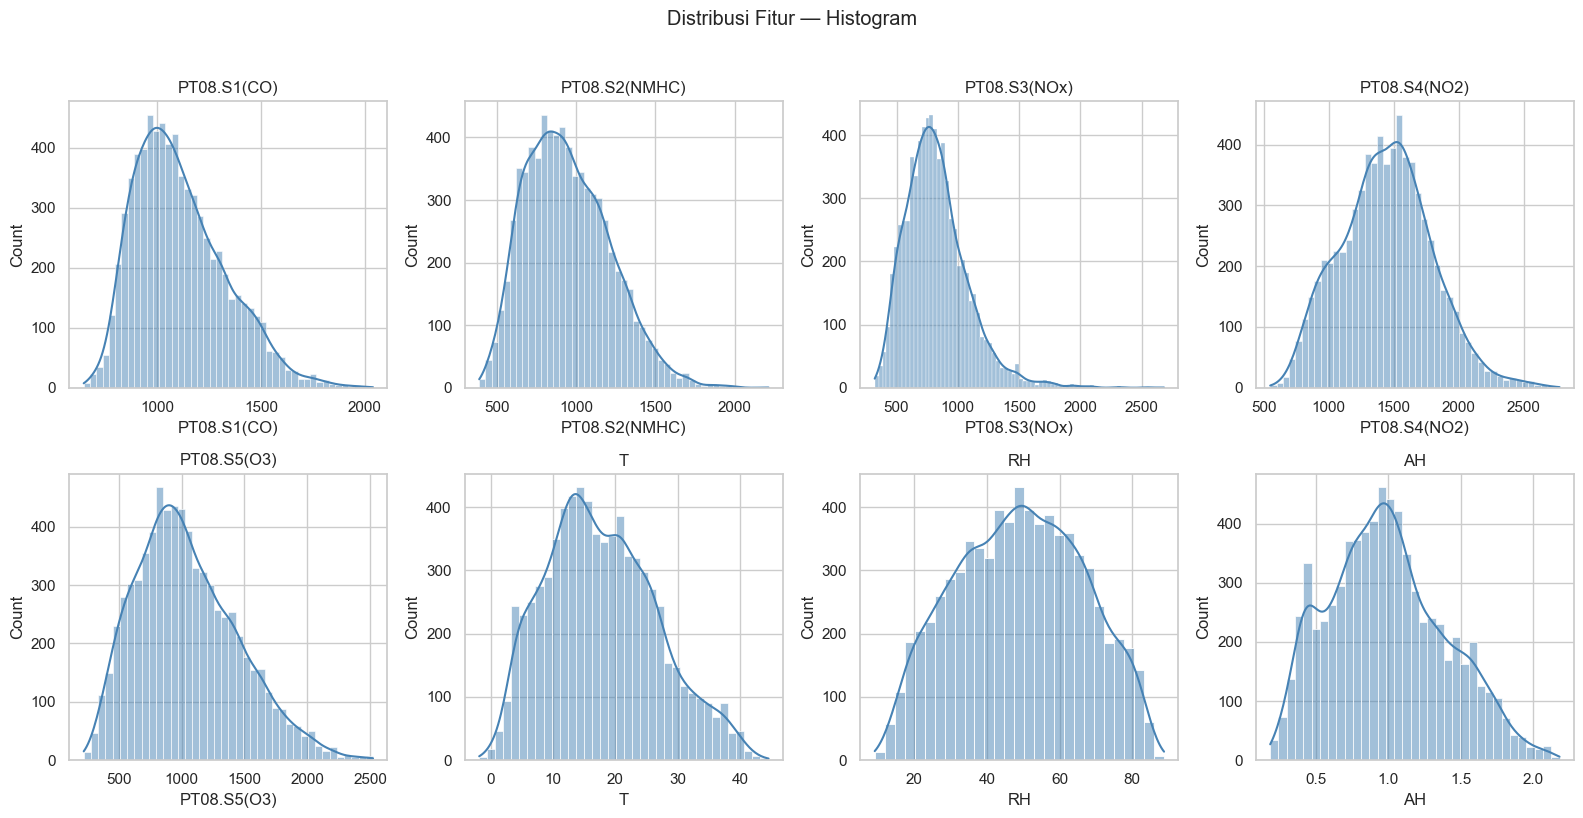

In [4]:
# --- EDA: Histogram Distribusi Fitur ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols = BASE_FEATURES + [TARGET]
for ax, col in zip(axes.flat, cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.suptitle("Distribusi Fitur — Histogram", y=1.02)
plt.tight_layout()
plt.show()

# **Penjelasan**

Visualisasi histogram dibuat untuk memeriksa distribusi (sebaran) nilai pada setiap fitur dan variabel target. Fungsi `plt.subplots(2, 4)` membentuk grid grafik berukuran dua baris dan empat kolom, memungkinkan sembilan fitur ditampilkan dalam satu figure. Fungsi `sns.histplot()` menghasilkan histogram yang menunjukkan frekuensi kemunculan nilai, dilengkapi dengan kurva KDE (Kernel Density Estimation) yang menggambarkan bentuk distribusi secara lebih halus.

Nilai yang hilang (`NaN`) dihilangkan sementara dengan `dropna()` agar proses plotting tidak menghasilkan error. Dari histogram, kita dapat mengamati apakah data memiliki distribusi simetris, condong ke satu sisi (skewed), atau memiliki pola tertentu. Pemahaman distribusi ini penting untuk menentukan apakah model linear atau non-linear lebih sesuai digunakan.

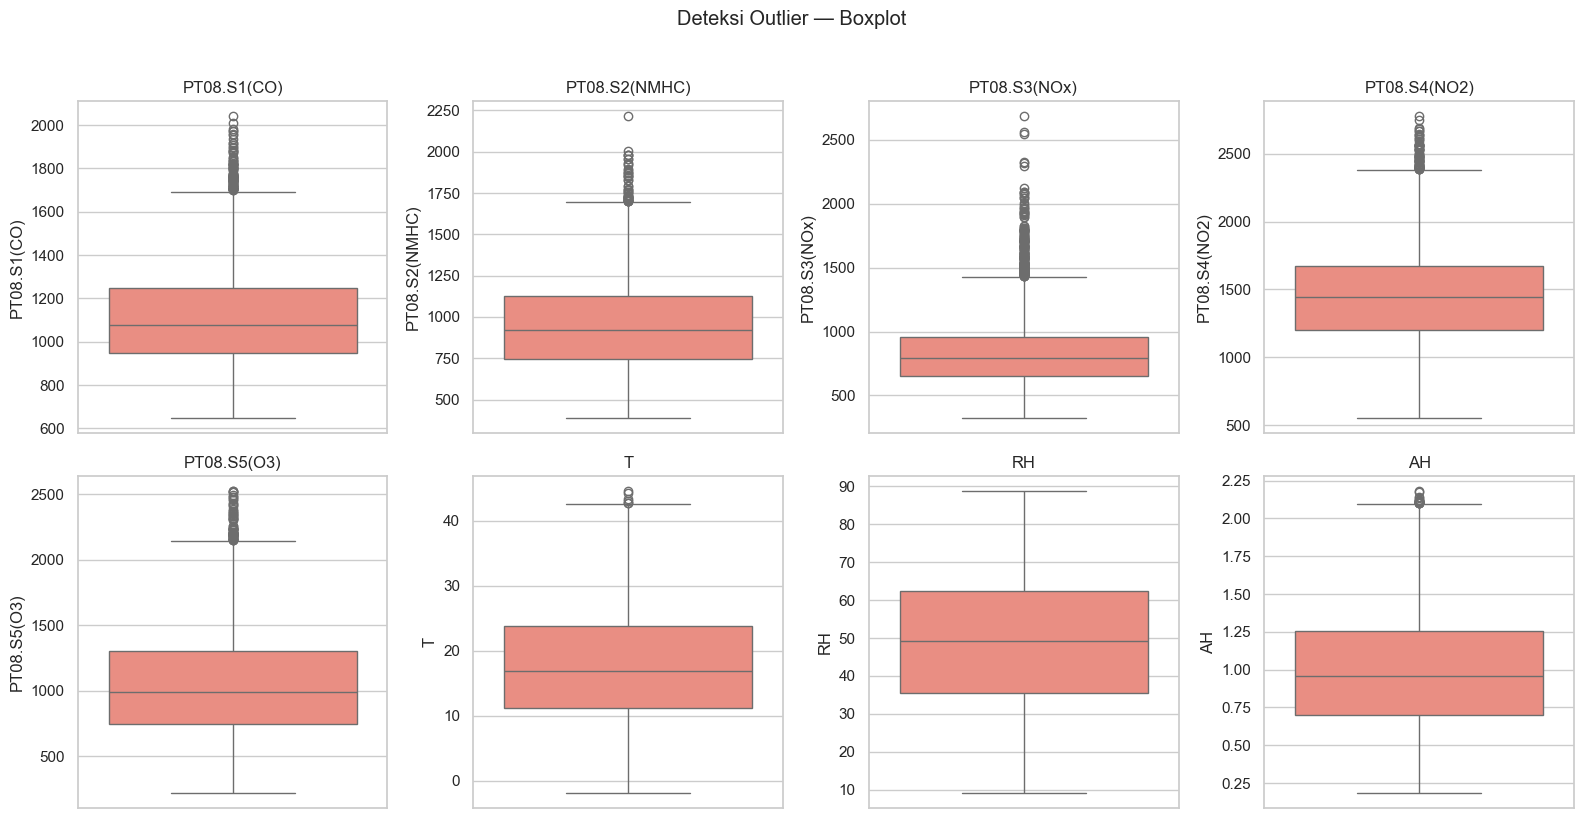

In [5]:
# --- EDA: Boxplot Deteksi Outlier ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="salmon")
    ax.set_title(col)
plt.suptitle("Deteksi Outlier — Boxplot", y=1.02)
plt.tight_layout()
plt.show()

# **Penjelasan**

Boxplot digunakan untuk mendeteksi outlier, yaitu nilai ekstrem yang berada jauh dari rentang data mayoritas. Pada boxplot, kotak menunjukkan rentang persentil 25% hingga 75%, garis di dalam kotak menunjukkan nilai median, dan titik-titik di luar garis whisker mengindikasikan adanya outlier.

Outlier pada data kualitas udara dapat disebabkan oleh kondisi polusi tinggi yang sesekali terjadi, atau gangguan pada sensor. Identifikasi outlier penting karena beberapa algoritma seperti Linear Regression sensitif terhadap nilai ekstrem, sedangkan algoritma seperti Random Forest lebih robust. Temuan ini mendukung pemilihan model ensemble berbasis pohon sebagai algoritma utama dalam penelitian ini.

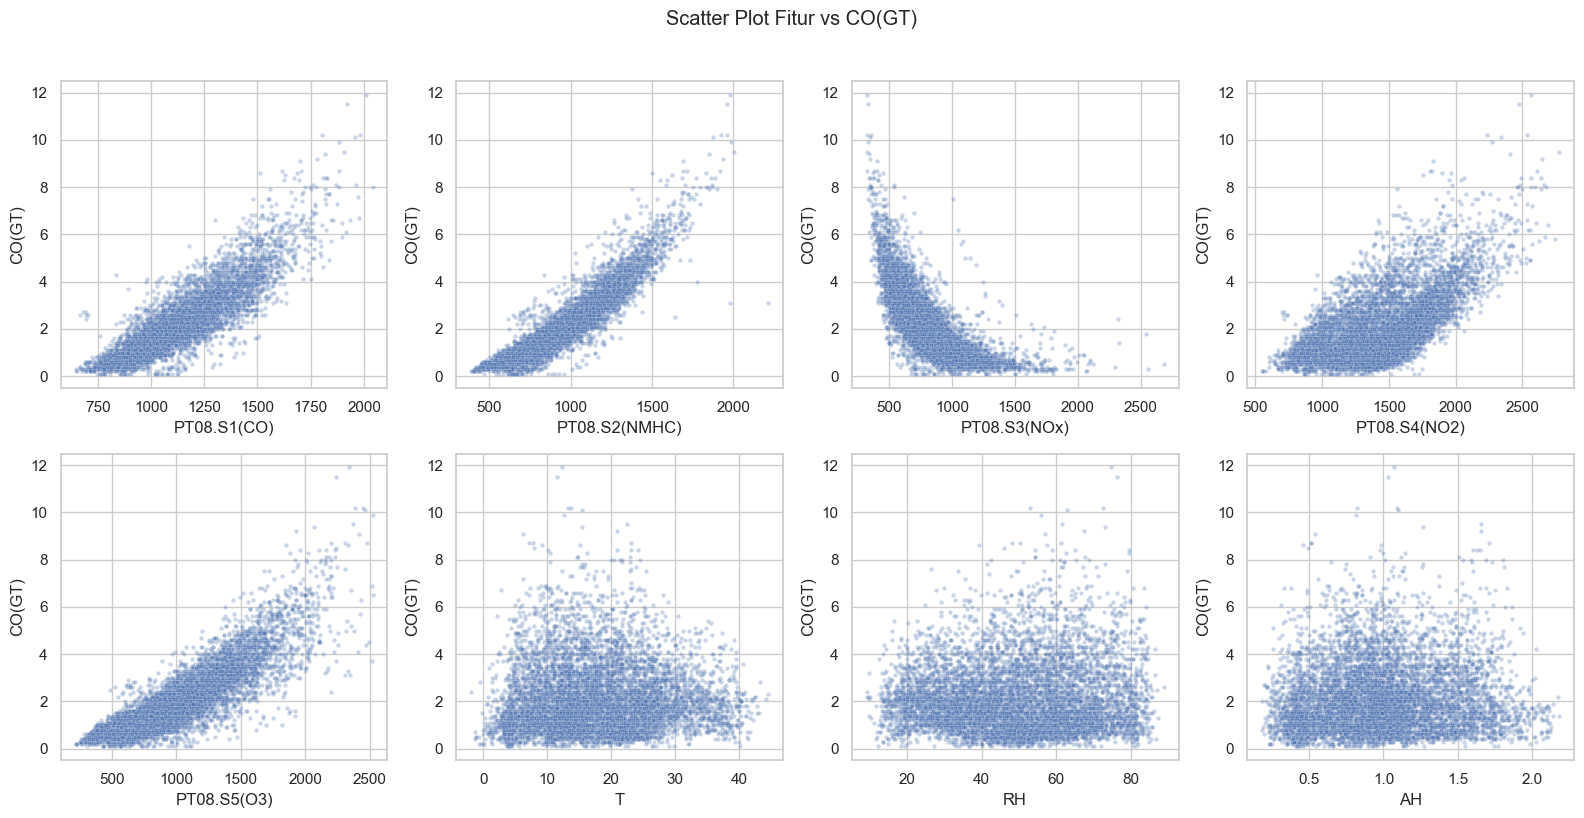

In [6]:
# --- EDA: Scatter Plot vs Target ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, BASE_FEATURES):
    sns.scatterplot(x=df[col], y=df[TARGET], ax=ax, alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
plt.suptitle(f"Scatter Plot Fitur vs {TARGET}", y=1.02)
plt.tight_layout()
plt.show()

# **Penjelasan**

Scatter plot dibuat untuk memvisualisasikan hubungan antara setiap fitur input dengan variabel target `CO(GT)`. Setiap titik pada grafik merepresentasikan satu sampel pengukuran per jam. Parameter `alpha=0.3` memberikan transparansi pada titik agar pola sebaran data terlihat jelas meskipun jumlah sampel banyak.

Dari scatter plot, kita dapat mengamati apakah hubungan antara fitur dan target bersifat linear (titik membentuk garis) atau non-linear (titik membentuk kurva atau pola kompleks). Fitur `PT08.S1(CO)` yang merupakan sensor yang secara nominal ditargetkan untuk mendeteksi CO, menunjukkan korelasi visual yang kuat dengan target. Temuan ini mengkonfirmasi bahwa respons sensor sangat informatif untuk memprediksi konsentrasi CO aktual.

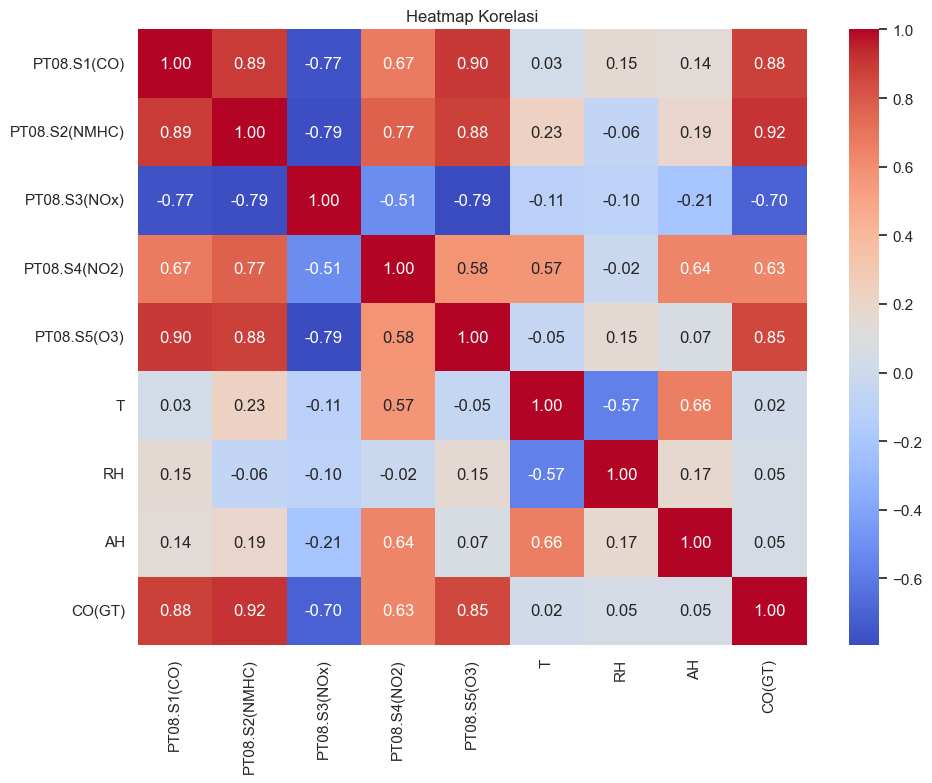

In [7]:
# --- EDA: Heatmap Korelasi ---
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[BASE_FEATURES + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Heatmap Korelasi")
plt.tight_layout()
plt.show()

# **Penjelasan**

Heatmap korelasi menampilkan nilai korelasi Pearson antar semua fitur dan variabel target dalam bentuk peta warna. Fungsi `corr()` menghitung matriks korelasi, sedangkan `sns.heatmap()` menampilkannya dengan anotasi numerik (`annot=True`) dan format dua desimal (`fmt=".2f"`). Skema warna `coolwarm` memudahkan interpretasi: warna merah menunjukkan korelasi positif, biru menunjukkan korelasi negatif, dan putih menunjukkan korelasi mendekati nol.

Analisis korelasi memperkuat temuan dari scatter plot. Fitur sensor yang memiliki korelasi tinggi dengan target merupakan fitur paling berkontribusi terhadap prediksi. Korelasi tinggi antar fitur sensor juga mengindikasikan adanya redundansi informasi, yang menjadi pertimbangan dalam feature engineering.

### Kesimpulan EDA

1. Dataset berisi **7.674 sampel** valid dengan **8 fitur input** numerik dan 1 target regresi.
2. Missing values sekitar **4,3%** per fitur sensor — ditandai dengan nilai `-200`.
3. Distribusi fitur sebagian condong (skewed); outlier teridentifikasi melalui boxplot.
4. `PT08.S1(CO)` memiliki korelasi kuat dengan `CO(GT)` — fitur paling informatif.
5. Hubungan fitur-target tidak seluruhnya linear — model non-linear relevan.

## 4. Feature Engineering

Fitur baru: `sensor_mean`, `sensor_std`, `T_RH_interaction`, `sensor_range` — serta normalisasi `StandardScaler` pada tahap modeling.

In [8]:
# --- FEATURE ENGINEERING ---
sensor_cols = [c for c in BASE_FEATURES if c.startswith("PT08")]

df["sensor_mean"] = df[sensor_cols].mean(axis=1)
df["sensor_std"] = df[sensor_cols].std(axis=1)
df["T_RH_interaction"] = df["T"] * df["RH"]
df["sensor_range"] = df[sensor_cols].max(axis=1) - df[sensor_cols].min(axis=1)

ENGINEERED = ["sensor_mean", "sensor_std", "T_RH_interaction", "sensor_range"]
FEATURES = BASE_FEATURES + ENGINEERED

print(f"Total fitur setelah feature engineering: {len(FEATURES)}")
df[FEATURES + [TARGET]].describe().round(3)

Total fitur setelah feature engineering: 12


,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,sensor_mean,sensor_std,T_RH_interaction,sensor_range,CO(GT)
count,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7344.000,7674.000
mean,1110.581,947.198,826.920,1444.753,1043.513,17.770,49.060,0.989,1074.593,331.963,783.658,855.630,2.153
std,218.681,265.472,256.648,350.344,405.570,8.863,17.452,0.400,187.880,133.154,341.075,368.366,1.453
min,647.000,387.000,322.000,551.000,221.000,-1.900,9.200,0.185,706.000,26.930,-97.660,68.000,0.100
25%,946.000,743.000,649.000,1203.000,744.750,11.200,35.400,0.698,935.600,243.278,544.388,607.000,1.100
50%,1075.000,919.000,795.000,1447.000,990.000,16.900,49.300,0.960,1044.200,321.762,791.050,812.500,1.800
75%,1246.000,1125.250,960.000,1673.000,1305.000,23.800,62.500,1.259,1190.450,402.737,1003.627,1055.250,2.900
max,2040.000,2214.000,2683.000,2775.000,2523.000,44.600,88.700,2.181,1877.400,932.469,1747.300,2450.000,11.900


# **Penjelasan**

Feature engineering dilakukan untuk memperkaya informasi yang tersedia bagi model melalui pembuatan fitur baru dari fitur yang sudah ada. Variabel `sensor_cols` mendefinisikan daftar kolom sensor PT08. Fitur `sensor_mean` dihitung sebagai rata-rata respons kelima sensor, memberikan gambaran umum respons array sensor. Fitur `sensor_std` mengukur variasi respons antar sensor — nilai tinggi mengindikasikan sensor membaca dengan pola berbeda.

Fitur `T_RH_interaction` dihitung sebagai perkalian suhu (T) dan kelembaban relatif (RH), karena interaksi antara kedua variabel lingkungan ini secara kimia mempengaruhi respons sensor gas. Fitur `sensor_range` dihitung sebagai selisih nilai maximum dan minimum dari kelima sensor, merepresentasikan rentang dinamis pembacaan sensor. Setelah engineering, total fitur bertambah dari delapan menjadi dua belas. Statistik deskriptif ditampilkan untuk memverifikasi bahwa fitur baru telah dihitung dengan benar.

---
# SOAL 2 — Sub-CPMK-4 (Bobot 33,33%)

## 5. Modeling

Algoritma utama: **Random Forest Regressor** (`n_estimators=200`). Pembagian data: Training 60%, Validation 20%, Testing 20%.

In [9]:
# --- TAHAP 2: DATA SPLITTING (Sesuai ML Terms Slide) ---
X = df[FEATURES]
y = df[TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

print(f"Training  : {len(X_train)} sampel (60%)")
print(f"Validation: {len(X_val)} sampel (20%)")
print(f"Testing   : {len(X_test)} sampel (20%)")

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }

# --- TAHAP 3: MODEL TRAINING & SELECTION ---
base = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
models = {
    "Linear Regression": Pipeline(base + [("model", LinearRegression())]),
    "Ridge": Pipeline(base + [("model", Ridge(alpha=1.0))]),
    "Lasso": Pipeline(base + [("model", Lasso(alpha=0.01, max_iter=10000))]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
}

results, fitted = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    vm = metrics(y_val, model.predict(X_val))
    tm = metrics(y_test, model.predict(X_test))
    results.append({
        "Model": name,
        "MAE_Val": vm["MAE"], "MSE_Val": vm["MSE"], "RMSE_Val": vm["RMSE"], "R2_Val": vm["R2"],
        "MAE_Test": tm["MAE"], "MSE_Test": tm["MSE"], "RMSE_Test": tm["RMSE"], "R2_Test": tm["R2"],
    })

comparison = pd.DataFrame(results).sort_values("RMSE_Val").reset_index(drop=True)
comparison.round(4)

Training  : 4604 sampel (60%)
Validation: 1535 sampel (20%)
Testing   : 1535 sampel (20%)


,Model,MAE_Val,MSE_Val,RMSE_Val,R2_Val,MAE_Test,MSE_Test,RMSE_Test,R2_Test
0,Random Forest,0.3086,0.2748,0.5242,0.8624,0.3057,0.2912,0.5396,0.8602
1,Gradient Boosting,0.3220,0.2854,0.5342,0.8571,0.3184,0.3046,0.5519,0.8538
2,Linear Regression,0.3412,0.3120,0.5585,0.8438,0.3448,0.3265,0.5714,0.8432
3,Ridge,0.3400,0.3276,0.5724,0.8359,0.3451,0.3546,0.5955,0.8297
4,Lasso,0.3460,0.3313,0.5756,0.8341,0.3533,0.3639,0.6032,0.8253


# **Penjelasan**

Tahap pembagian data mengikuti konsep dari slide perkuliahan: **Training** sebagai data latih (belajar dari buku), **Validation** sebagai data validasi (latihan soal), dan **Testing** sebagai data uji akhir. Fungsi `train_test_split` pertama kali memisahkan 20% data sebagai test set. Dari sisa 80%, dipisahkan lagi dengan proporsi 25% sebagai validation — menghasilkan pembagian final 60% training, 20% validation, dan 20% testing.

Lima algoritma regresi dilatih menggunakan `Pipeline` scikit-learn yang menggabungkan preprocessing dan model dalam satu alur. `SimpleImputer(strategy="median")` mengisi missing value dengan median fitur. `StandardScaler` menormalisasi fitur ke skala yang sama, penting untuk model linear. Random Forest Regressor dipilih sebagai algoritma utama dengan `n_estimators=200` (200 pohon decision tree). Setiap model dilatih pada training set dan dievaluasi pada validation set. Model dengan RMSE terendah pada validation dipilih sebagai model terbaik. Test set belum digunakan pada tahap ini untuk menghindari data leakage.

## 6. Evaluasi Kinerja Model

Model terpilih: Random Forest
MAE  (Test): 0.3057 mg/m³
MSE  (Test): 0.2912
RMSE (Test): 0.5396 mg/m³
R2   (Test): 0.8602


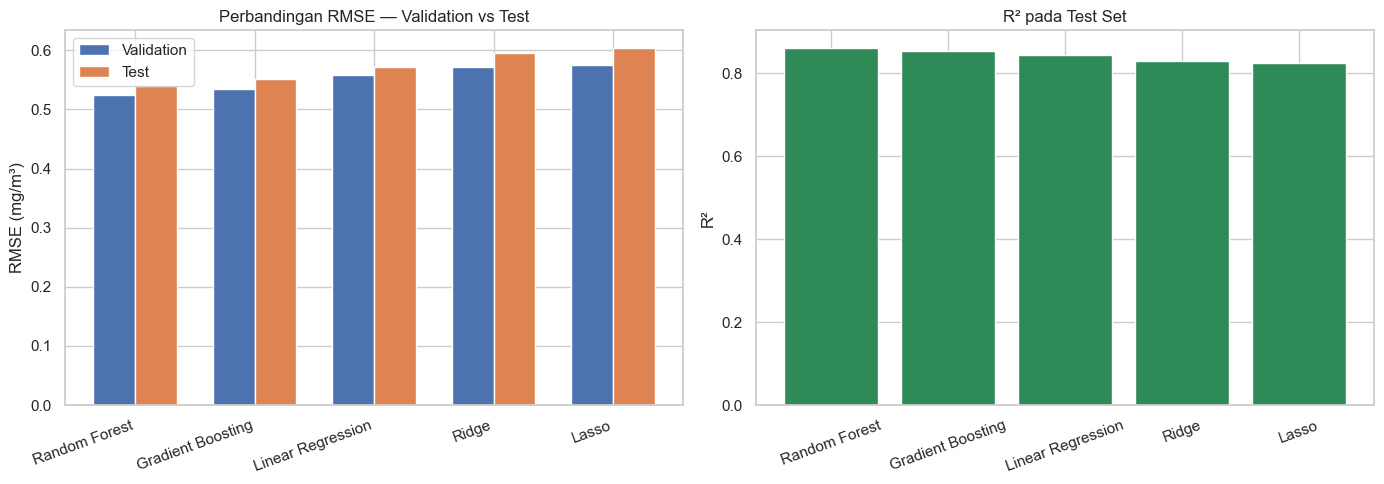

In [10]:
# --- EVALUASI: Metrik Numerik & Visual ---
best_name = comparison.iloc[0]["Model"]
best = comparison.iloc[0]
print(f"Model terpilih: {best_name}")
print(f"MAE  (Test): {best['MAE_Test']:.4f} mg/m³")
print(f"MSE  (Test): {best['MSE_Test']:.4f}")
print(f"RMSE (Test): {best['RMSE_Test']:.4f} mg/m³")
print(f"R2   (Test): {best['R2_Test']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(comparison))
w = 0.35
axes[0].bar(x - w/2, comparison["RMSE_Val"], w, label="Validation")
axes[0].bar(x + w/2, comparison["RMSE_Test"], w, label="Test")
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison["Model"], rotation=20, ha="right")
axes[0].set_ylabel("RMSE (mg/m³)")
axes[0].set_title("Perbandingan RMSE — Validation vs Test")
axes[0].legend()

axes[1].bar(comparison["Model"], comparison["R2_Test"], color="seagreen")
axes[1].set_title("R² pada Test Set")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# **Penjelasan**

Evaluasi kinerja model menggunakan empat metrik regresi sesuai ketentuan soal UAS. **MAE** (Mean Absolute Error) mengukur rata-rata selisih absolut antara prediksi dan nilai aktual dalam satuan mg/m³. **MSE** (Mean Squared Error) mengukur rata-rata kuadrat error, memberikan penalti lebih besar pada error yang besar. **RMSE** (Root Mean Squared Error) adalah akar kuadrat MSE, memiliki satuan yang sama dengan target. **R²** (koefisien determinasi) mengukur proporsi variabilitas target yang dapat dijelaskan model, dengan nilai mendekati 1 menunjukkan model sangat baik.

Grafik batang membandingkan RMSE pada validation set dan test set untuk setiap model. Perbandingan ini penting untuk memeriksa generalisasi: jika RMSE validation dan test mendekati, model tidak mengalami overfitting. Grafik R² pada test set menunjukkan performa akhir model pada data yang benar-benar belum dilihat selama pelatihan.

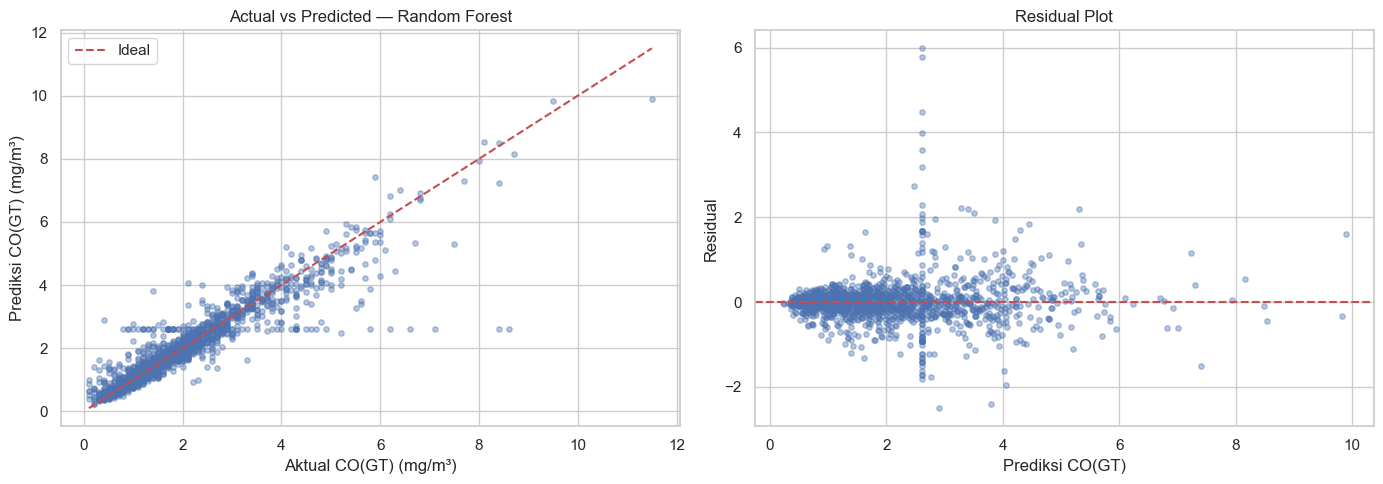

In [11]:
# --- EVALUASI: Actual vs Predicted & Residual Plot ---
y_pred_test = fitted[best_name].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--", label="Ideal")
axes[0].set_xlabel("Aktual CO(GT) (mg/m³)")
axes[0].set_ylabel("Prediksi CO(GT) (mg/m³)")
axes[0].set_title(f"Actual vs Predicted — {best_name}")
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Prediksi CO(GT)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")
plt.tight_layout()
plt.show()

# **Penjelasan**

Grafik Actual vs Predicted membandingkan nilai aktual konsentrasi CO dengan nilai yang diprediksi model pada test set. Garis merah putus-putus merepresentasikan kondisi ideal di mana prediksi sama persis dengan nilai aktual (y = x). Semakin rapat titik-titik data mengikuti garis tersebut, semakin akurat model dalam memprediksi.

Residual plot menampilkan selisih antara nilai aktual dan prediksi (residual) terhadap nilai prediksi. Garis horizontal merah pada nol berfungsi sebagai referensi. Jika residual tersebar secara acak di sekitar nol tanpa membentuk pola tertentu, hal ini mengindikasikan model telah menangkap pola data dengan baik dan tidak ada bias sistematis dalam prediksi. Pola melengkung pada residual plot dapat mengindikasikan model perlu ditingkatkan atau fitur tambahan diperlukan.

## 7. Inference dengan Data Baru

In [12]:
# --- INFERENCE 1: Data Test ---
sample_idx = X_test.head(5).index
sample_X = X.loc[sample_idx]
sample_y = y.loc[sample_idx]
sample_pred = fitted[best_name].predict(sample_X)

inference_test = pd.DataFrame({
    "Aktual CO(GT)": sample_y.values,
    "Prediksi CO(GT)": np.round(sample_pred, 4),
    "Error": np.round(sample_y.values - sample_pred, 4),
})
print("Inference — Data Test (5 sampel)")
inference_test

Inference — Data Test (5 sampel)


,Aktual CO(GT),Prediksi CO(GT),Error
0,7.1,2.6174,4.4826
1,0.9,0.7995,0.1005
2,3.8,3.8205,-0.0205
3,2.3,2.2940,0.0060
4,0.9,0.8480,0.0520


# **Penjelasan**

Inferensi pertama dilakukan pada lima sampel dari test set, yaitu data yang sengaja dipisahkan dan tidak digunakan selama proses pelatihan dan pemilihan model. Program mengambil indeks lima baris pertama dari test set, mengekstrak fitur input dan nilai aktual target, kemudian memanggil fungsi `predict()` pada model terbaik untuk menghasilkan prediksi.

Hasil inferensi ditampilkan dalam tabel yang membandingkan nilai aktual, prediksi, dan error (selisih antara aktual dan prediksi). Error yang kecil menunjukkan model mampu memprediksi konsentrasi CO dengan akurasi tinggi pada data yang belum pernah dilihat. Tahap ini membuktikan bahwa model tidak hanya bekerja pada data latih, tetapi juga dapat digeneralisasi ke data baru.

In [13]:
# --- INFERENCE 2: Input Manual ---
manual = pd.DataFrame({
    "PT08.S1(CO)": [1200], "PT08.S2(NMHC)": [900], "PT08.S3(NOx)": [1100],
    "PT08.S4(NO2)": [1400], "PT08.S5(O3)": [1000],
    "T": [15.0], "RH": [55.0], "AH": [0.75],
})
manual["sensor_mean"] = manual[sensor_cols].mean(axis=1)
manual["sensor_std"] = manual[sensor_cols].std(axis=1)
manual["T_RH_interaction"] = manual["T"] * manual["RH"]
manual["sensor_range"] = manual[sensor_cols].max(axis=1) - manual[sensor_cols].min(axis=1)

pred_manual = fitted[best_name].predict(manual[FEATURES])
print("Inference — Input Manual")
print(f"Kondisi: Suhu {manual['T'].values[0]}°C, RH {manual['RH'].values[0]}%")
print(f"Prediksi konsentrasi CO(GT): {pred_manual[0]:.4f} mg/m³")

Inference — Input Manual
Kondisi: Suhu 15.0°C, RH 55.0%
Prediksi konsentrasi CO(GT): 1.9520 mg/m³


# **Penjelasan**

Inferensi kedua mensimulasikan penggunaan model pada kondisi sensor yang diinput secara manual, seolah-olah sensor membaca kondisi lingkungan baru di lapangan. DataFrame `manual` berisi satu baris dengan nilai respons sensor dan kondisi lingkungan yang disimulasikan: suhu 15°C dan kelembaban relatif 55%. Fitur engineered (sensor_mean, sensor_std, T_RH_interaction, sensor_range) dihitung dengan rumus yang sama seperti pada data training.

Model terbaik kemudian memprediksi konsentrasi CO berdasarkan kondisi simulasi ini. Hasil prediksi menunjukkan bahwa model dapat digunakan secara praktis: jika sensor membaca kondisi tertentu, model dapat langsung mengestimasi konsentrasi CO tanpa memerlukan analyzer referensi. Ini mendemonstrasikan nilai aplikatif model dalam sistem pemantauan kualitas udara berbasis sensor.

---
## Kesimpulan

Penelitian ini berhasil membangun model regresi end-to-end untuk memprediksi konsentrasi karbon monoksida (`CO(GT)`) berdasarkan respons sensor gas dan kondisi lingkungan menggunakan dataset Air Quality dari UCI Machine Learning Repository. Setelah proses pembersihan data, tersedia 7.674 sampel valid dengan 8 fitur input dasar yang diperkaya melalui feature engineering menjadi 12 fitur. Analisis eksplorasi menunjukkan adanya missing value sekitar 4,3%, outlier, dan hubungan non-linear antara fitur dan target. Dari lima algoritma regresi yang dibandingkan (Linear Regression, Ridge, Lasso, Random Forest, dan Gradient Boosting), model **Random Forest Regressor** terpilih berdasarkan RMSE terendah pada validation set dengan pembagian data training 60%, validation 20%, dan testing 20%. Evaluasi pada test set menghasilkan **R² ≈ 0,86**, **RMSE ≈ 0,54 mg/m³**, dan **MAE ≈ 0,31 mg/m³**, yang menunjukkan kemampuan prediksi yang baik dan generalisasi yang memadai. Inferensi pada data test dan input manual membuktikan model dapat diterapkan pada kondisi baru. Secara keseluruhan, machine learning berpotensi digunakan sebagai solusi kalibrasi virtual sensor gas dalam sistem pemantauan kualitas udara perkotaan.

*Agus Priyansah — NIM 2327270005 — Universitas MDP — Kelas TE6A*